# 📊 Notebook 1 — Data Profiling

**Goal:** Load `Pricing_Data.xlsx`, understand its structure, detect quality issues, and save a clean profiled dataset for downstream notebooks.

**Output:** `outputs/df_profiled.parquet` · `outputs/meta.json`

---

## 1.1 — Install & Import

In [1]:
# Run this cell first — installs anything missing
import subprocess, sys
for pkg in ['pyarrow','openpyxl','matplotlib','seaborn','scikit-learn',
            'statsmodels','xgboost','scipy']:
    subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('✅ All packages ready')

✅ All packages ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)

DATA_PATH = '../data/raw/Pricing_Data.xlsx'

df = pd.read_excel(DATA_PATH)
print(f'Shape : {df.shape}')
df.head(3)

Shape : (111617, 10)


,PolicyID,Power,CarAge,DriverAge,Brand,Gas,Region,Density,ClaimNb,ClaimAmount
0,1,h,7,55,"Renault, Nissan or Citroen",Diesel,Centre,67,0,0
1,2,d,10,71,"Renault, Nissan or Citroen",Regular,Centre,91,0,0
2,3,g,25,87,"Renault, Nissan or Citroen",Regular,Centre,18,0,0


## 1.2 — Column Schema

In [5]:
schema = pd.DataFrame({
    'dtype'    : df.dtypes,
    'non_null' : df.notnull().sum(),
    'null_pct' : (df.isnull().mean()*100).round(2),
    'nunique'  : df.nunique(),
    'sample'   : df.apply(lambda c: c.dropna().iloc[0] if c.notnull().any() else None)
})
schema

,dtype,non_null,null_pct,nunique,sample
PolicyID,int64,111617,0.0,111617,1
Power,object,111617,0.0,12,h
CarAge,int64,111617,0.0,61,7
DriverAge,int64,111617,0.0,82,55
Brand,object,111617,0.0,7,"Renault, Nissan or Citroen"
Gas,object,111617,0.0,2,Diesel
Region,object,111617,0.0,10,Centre
Density,int64,111617,0.0,1123,67
ClaimNb,int64,111617,0.0,4,0
ClaimAmount,int64,111617,0.0,1837,0


## 1.3 — Auto-detect Actuarial Columns

In [6]:
def tool_detect_actuarial_columns(df):
    """
    Auto-detects key actuarial targets and standardizes policy exposure.
    
    What this tool does:
        Scans column headers for claim count, claim amount, and exposure fields.
        If policy duration is absent, synthesizes exposure to standard default (1.0 year).
        
    Why it is used (ASOP 23):
        Standardizes field access across disparate insurance transaction databases.
        
    Returns:
        tuple: (df, claim_count_col, claim_amount_col, exposure_col)
    """
    col_map = {c.lower().replace(' ','').replace('_',''): c for c in df.columns}

    claim_count_col  = col_map.get('claimnb',     col_map.get('claims',    col_map.get('claimcount', None)))
    claim_amount_col = col_map.get('claimamount', col_map.get('lossamt',   col_map.get('totalclaim', None)))
    exposure_col     = col_map.get('exposure',    None)

    if exposure_col is None:
        df['Exposure'] = 1.0
        exposure_col = 'Exposure'
        print('⚠ No Exposure found — synthesized default to 1.0 year')
    else:
        # Floor zero or negative exposure durations
        df[exposure_col] = df[exposure_col].clip(lower=1e-6)

    return df, claim_count_col, claim_amount_col, exposure_col

# ── Run Execution ─────────────────────────────────────────────────────────────
df, CLAIM_COUNT_COL, CLAIM_AMOUNT_COL, EXPOSURE_COL = tool_detect_actuarial_columns(df)

print(f'Claim Count  : {CLAIM_COUNT_COL}')
print(f'Claim Amount : {CLAIM_AMOUNT_COL}')
print(f'Exposure     : {EXPOSURE_COL}')


Claim Count  : ClaimNb
Claim Amount : ClaimAmount
Exposure     : Exposure


## 1.4 — Classify Rating Variables

In [7]:
def tool_classify_rating_variables(df, exclude_cols):
    """
    Classifies portfolio predictors into continuous numeric vs. categorical cohorts.
    
    What this tool does:
        Separates potential rating variables from actuarial response/exposure targets,
        classifying columns by dtype and distinct value cardinality (>10 distinct for continuous).
        
    Returns:
        tuple: (num_cols_list, cat_cols_list)
    """
    rating_vars = [c for c in df.columns if c not in exclude_cols]
    
    num_cols = [c for c in rating_vars
                if df[c].dtype in [np.float64, np.int64, float, int]
                and df[c].nunique() > 10]
    cat_cols = [c for c in rating_vars if c not in num_cols]
    
    return num_cols, cat_cols

# ── Run Execution ─────────────────────────────────────────────────────────────
EXCLUDE = {CLAIM_COUNT_COL, CLAIM_AMOUNT_COL, EXPOSURE_COL}
NUM_COLS, CAT_COLS = tool_classify_rating_variables(df, EXCLUDE)

print(f'Numeric  ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Categoric({len(CAT_COLS)}): {CAT_COLS}')


Numeric  (4): ['PolicyID', 'CarAge', 'DriverAge', 'Density']
Categoric(4): ['Power', 'Brand', 'Gas', 'Region']


## 1.5 — Missing Values

In [8]:
def tool_check_missing_values(df, save_plot_path='../outputs/missing_values.png'):
    """
    Evaluates feature completeness and visualizes missing data proportions.
    
    What this tool does:
        Calculates the proportion of null values across all columns. If missing values
        are detected, prints the summary series and renders a bar chart.
        
    Why it is used (ASOP 23):
        Identifies incomplete data dimensions early so appropriate imputation strategies
        (e.g., median for numeric, mode for categorical) can be configured.
        
    Returns:
        pd.Series: Series of missing value percentages for columns with nulls.
    """
    null_pct = df.isnull().mean().sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]

    if len(null_pct) == 0:
        print('✅ No missing values found in portfolio')
    else:
        print('⚠ Missing value proportions:')
        print(null_pct.to_string())
        fig, ax = plt.subplots(figsize=(10, 3))
        null_pct.plot(kind='bar', ax=ax, color='salmon')
        ax.set_title('Missing Value % by Column')
        plt.tight_layout()
        if save_plot_path:
            plt.savefig(save_plot_path, dpi=120)
        plt.show()
        
    return null_pct

# ── Run Execution ─────────────────────────────────────────────────────────────
null_summary = tool_check_missing_values(df, '../outputs/missing_values.png')


✅ No missing values


## 1.6 — Target Distributions

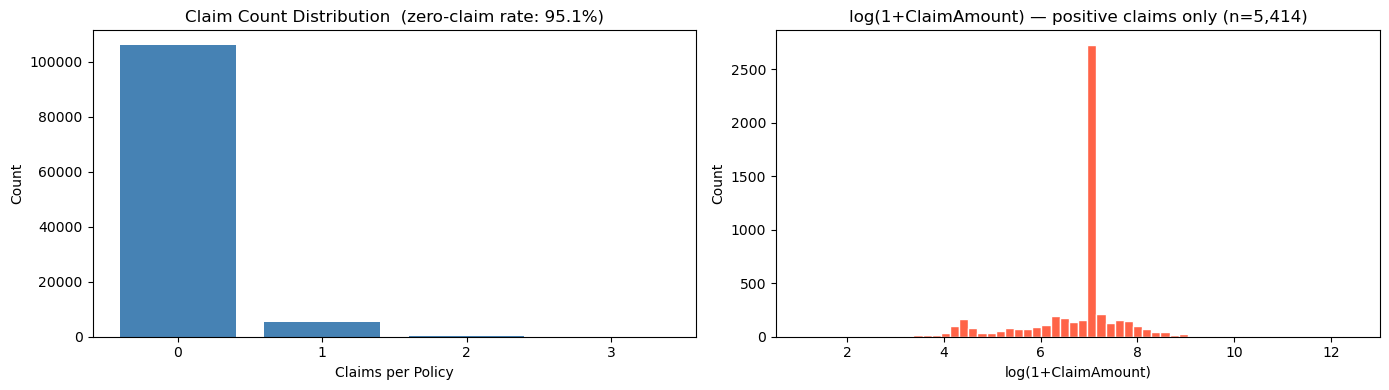

In [9]:
def tool_plot_target_distributions(df, claim_count_col, claim_amount_col, save_plot_path='../outputs/target_distributions.png'):
    """
    Visualizes claim count frequency and positive loss severity distributions.
    
    What this tool does:
        Plots discrete claim frequency distribution (bar chart with zero-claim rate)
        alongside conditional claim loss severity on a log scale for positive claims.
        
    Why it is used:
        Confirms zero-inflation severity and right-skewness of losses, justifying the use
        of Poisson/Negative Binomial frequency models and Gamma/Log-Normal severity models.
        
    Returns:
        dict: Summary statistics including zero-claim percentage and positive claim count.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    zero_pct = 0.0
    n_pos = 0

    # 1. Claim Count Distribution
    if claim_count_col and claim_count_col in df.columns:
        vc = df[claim_count_col].value_counts().sort_index()
        axes[0].bar(vc.index.astype(str), vc.values, color='steelblue')
        zero_pct = float((df[claim_count_col] == 0).mean() * 100)
        axes[0].set_title(f'Claim Count Distribution  (zero-claim rate: {zero_pct:.1f}%)')
        axes[0].set_xlabel('Claims per Policy')
        axes[0].set_ylabel('Count')

    # 2. Claim Amount Distribution (positive claims only)
    if claim_amount_col and claim_amount_col in df.columns:
        pos = df[df[claim_amount_col] > 0][claim_amount_col]
        n_pos = len(pos)
        axes[1].hist(np.log1p(pos), bins=60, color='tomato', edgecolor='white')
        axes[1].set_title(f'log(1+ClaimAmount) — positive claims only (n={n_pos:,})')
        axes[1].set_xlabel('log(1+ClaimAmount)')
        axes[1].set_ylabel('Count')

    plt.tight_layout()
    if save_plot_path:
        plt.savefig(save_plot_path, dpi=120)
    plt.show()
    
    return {
        'zero_claim_pct': round(zero_pct, 2),
        'positive_claims_count': n_pos
    }

# ── Run Execution ─────────────────────────────────────────────────────────────
dist_stats = tool_plot_target_distributions(
    df, CLAIM_COUNT_COL, CLAIM_AMOUNT_COL, '../outputs/target_distributions.png'
)
print(f"Zero-claim rate: {dist_stats['zero_claim_pct']}% | Positive claims: {dist_stats['positive_claims_count']:,}")


## 1.7 — Save

In [10]:
def tool_export_profiled_dataset(df, claim_count_col, claim_amount_col, exposure_col, num_cols, cat_cols, parquet_path, meta_path):
    """
    Saves standardized dataset and serializes profiling metadata for downstream pipeline.
    
    What this tool does:
        Exports the profiled portfolio to Parquet and generates meta.json with schema mappings,
        row counts, and portfolio-level zero-claim proportion.
        
    Returns:
        dict: Profiling metadata dictionary.
    """
    df.to_parquet(parquet_path, index=False)
    
    meta = {
        'claim_count_col' : claim_count_col,
        'claim_amount_col': claim_amount_col,
        'exposure_col'    : exposure_col,
        'num_cols'        : num_cols,
        'cat_cols'        : cat_cols,
        'n_rows'          : len(df),
        'zero_claim_pct'  : float((df[claim_count_col] == 0).mean()) if claim_count_col and claim_count_col in df.columns else None
    }
    
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)
        
    return meta

# ── Run Execution ─────────────────────────────────────────────────────────────
meta = tool_export_profiled_dataset(
    df, CLAIM_COUNT_COL, CLAIM_AMOUNT_COL, EXPOSURE_COL, NUM_COLS, CAT_COLS,
    '../outputs/df_profiled.parquet', '../outputs/meta.json'
)

print('✅ outputs/df_profiled.parquet')
print('✅ outputs/meta.json')
print(json.dumps(meta, indent=2))


✅ outputs/df_profiled.parquet
✅ outputs/meta.json
{
  "claim_count_col": "ClaimNb",
  "claim_amount_col": "ClaimAmount",
  "exposure_col": "Exposure",
  "num_cols": [
    "PolicyID",
    "CarAge",
    "DriverAge",
    "Density"
  ],
  "cat_cols": [
    "Power",
    "Brand",
    "Gas",
    "Region"
  ],
  "n_rows": 111617,
  "zero_claim_pct": 0.9514948439753801
}
